<a href="https://colab.research.google.com/github/kankana2005-cloud/MAS/blob/main/SpeechEmotionRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RAVDESS is the dataset used for this project.What RAVDESS contains

RAVDESS includes recordings from 24 actors (12 male + 12 female). Each actor speaks sentences with different emotions.

How to read a RAVDESS filename

This is the most important part.

Example filename:

03-01-05-01-02-01-12.wav

RAVDESS filenames follow this format:

MM-VV-EE-II-SS-RR-AA


MM	Modality

VV	Vocal channel

EE	Emotion

II	Emotional intensity

SS	Statement

RR	Repetition

AA	Actor

apt-get---- is a package manager used in Ubuntu/Linux systems.

-y---Automatically answers YES to confirmation prompts.

libsndfile1----This is an audio processing library.

It helps Python libraries like:

librosa

soundfile

to:

read audio files

write audio files

In [ ]:
# Step 1: Install system library for soundfile (required to read .wav files)
!apt-get install -y libsndfile1

# Step 2: Install Python libraries. (We removed "pickle5" to avoid the error you saw)
!pip install librosa soundfile tensorflow scikit-learn pandas matplotlib numpy

# Step 3: Print a success message
print("✅ All libraries installed successfully!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libsndfile1 is already the newest version (1.0.31-2ubuntu0.2).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.
✅ All libraries installed successfully!


This code connects your Google Drive to the Google Colab notebook.

It allows your project to:

access datasets stored in Drive
,read audio files
,save trained models
,save outputs/results

In [ ]:
# Step 4: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


This command is used to view the files and folders inside your RAVDESS dataset directory stored in Google Drive.

In [ ]:
!ls "/content/drive/MyDrive/RAVDESS"

Audio_Song_Actors_01-24  Audio_Speech_Actors_01-24


Read audio---librosa, soundfile

Numerical calculations---	numpy

Store data---	pandas

Machine Learning---	scikit-learn

Deep Learning---	tensorflow

Graphs---	matplotlib

These libraries were imported to perform file handling, audio processing, feature extraction, preprocessing, machine learning/deep learning model training, evaluation, visualization, and model saving in the Speech Emotion Recognition project.

In [ ]:
import os
import numpy as np
import librosa
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

Save the dataset folder path into a variable named FOLDER_PATH

In [ ]:
FOLDER_PATH = '/content/drive/MyDrive/RAVDESS'

It converts raw speech audio into numerical features that the machine learning model can understand.

This function extracts:

ZCR----(Zero-Crossing Rate)What it is: The rate at which an audio signal changes its sign (from positive to negative or vice versa).What it measures: The "noisiness" or high-frequency activity of a signal.

Mel Spectrogram-----A visual representation of the frequencies in an audio signal over time, with the frequency axis adjusted to the Mel scale The distribution of energy across different audible pitch ranges over time.

MFCC----(Mel-Frequency Cepstral Coefficients)What it is: A highly condensed, mathematical representation of the "shape" of the vocal tract, created by taking a Mel Spectrogram and applying a Discrete Cosine Transform (DCT) to it

Chroma Features----- A representation that projects the entire audio spectrum into 12 bins representing the 12 semitones of the musical octave (C, C#, D, D#, etc.), also known as "pitch class profiles".

from an audio file.

In [ ]:
#This function extracts audio features.
# file_path-----	audio file location
#TRY BLOCK -- Attempts to load the audio file safely.
#librosa.load()---Loads audio into memory.
#and returns 2 things audio and sr
#audio--- audio waveform array Example:[0.12, -0.33, 0.56, ...] These numbers represent sound amplitude over time.
#sr-none---Keep the original sampling rate.
#then EXCEPTION handles error and the print line prints which file falied with error message as e
#return=none--Stops function execution if loading fails.

def extract_features(file_path, mfcc=True, chroma=True, mel=True, zcr=True):
    try:
        audio, sr = librosa.load(file_path, sr=None)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None
#Creates an empty list to store extracted features.Later:MFCC values,Mel values,ZCR values,Chroma values are added here.
    features = []

#if zcr:Checks whether ZCR extraction is enabled.(ZCR = Zero Crossing Rate Measures how often audio signal crosses zero.)
#zcr_val = librosa.feature.zero_crossing_rate(audio) ---- Calculates zero crossing rate.
#calculate mean and append
#calculate standard deviation and append
#Why Mean + Std? Mean:overall behavior   Std:variability   Both improve ML understanding.
    if zcr:
        zcr_val = librosa.feature.zero_crossing_rate(audio)
        features.append(np.mean(zcr_val))
        features.append(np.std(zcr_val))

#What is Mel Spectrogram?
#Represents audio frequencies based on human hearing perception.Humans don’t hear frequencies linearly.Mel scale mimics human hearing.
#n_mels=128 Uses 128 Mel frequency bands.More bands → more detailed frequency information.
#Converting Power to dB
#mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
#Why convert to decibel scale?
#Human hearing is logarithmic.dB representation is more meaningful.
    if mel:
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        features.append(np.mean(mel_spec_db))
        features.append(np.std(mel_spec_db))

#MFCC captures:tone,pitch,,timbre,vocal tract characteristics.Very useful for emotion detection.
#n_mfcc=13 Extracts 13 MFCC coefficients.13 is standard in speech processing.
#This means your final feature matrix will have 13 rows for every time frame. The 0-th coefficient gives general spectral shape (energy),
#while 1-12 capture the core timbral shape of the sound.
#Processes each MFCC vector individually.and then calculate mean and std

    if mfcc:
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        for coeff in mfccs:
            features.append(np.mean(coeff))
            features.append(np.std(coeff))

#What is Chroma?Chroma represents pitch classes.
#Uses Short-Time Fourier Transform.(stft).
#stft-It breaks down a continuous audio wave to show which frequencies are present at specific moments in time.
#for val in chroma:Processes chroma bands and store mean and std
#Converts feature list into NumPy array.Stores values as 32-bit floating-point numbers.Benefits:faster computation,lower memory usage

    if chroma:
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        for val in chroma:
            features.append(np.mean(val))
            features.append(np.std(val))
    return np.array(features, dtype=np.float32)

#FINAL OUTPUT OF FUNCTION
#Example:[0.12, 0.03, -45.7, 12.1, ...]A feature vector representing the audio.


This code creates a dictionary that maps emotion codes from the RAVDESS dataset to actual emotion names.


Why is this needed?

In the RAVDESS dataset, emotions are encoded as numbers inside filenames.

Example filename:

03-01-05-01-01-01-01.wav

Here:

05

represents the emotion code.

In [ ]:
emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}


This block is the dataset loading and preprocessing pipeline of your Speech Emotion Recognition project.

In [ ]:
print("🚀 Searching for all .wav files under:", FOLDER_PATH)

#Creates a function to find all WAV audio files inside folders and subfolders.
#root starting dataset directory
#Creates an empty list to store all WAV file paths.
#dirpath---current folder path
#dirnames---subfolders
#filenames---files in folder
#os.walk()---It recursively traverses folders.
#Loops through every file(f) in the current folder
#Ensures only audio files are selected whose name end with .wav
#os.path.join()--Combines folder path + filename safely.


def find_all_wav_files(root):
    """Return a list of full paths to all .wav files under root."""
    wav_files = []
    for dirpath, dirnames, filenames in os.walk(root):
        for f in filenames:
            if f.endswith('.wav'):
                wav_files.append(os.path.join(dirpath, f))
    return wav_files

#Runs the function using dataset folder path.
#Counts number of files. using len
#data stores	feature vectors
#labels stores	emotions

all_files = find_all_wav_files(FOLDER_PATH)
print(f"Found {len(all_files)} .wav files total.")
data = []
labels = []

#LOOPS THROUGH ALL THE FILES
#enumerate()--Provides:index number,file value
#%(Modulo operator)Checks remainder.Meaning:Every 200 files:print progress
#filename = os.path.basename(file_path)----Extracts filename from full path.
#Splits RAVDESS filename into components.
#Example
#03-01-05-01-01-01-01.wav  becomes:
#['03','01','05','01','01','01','01.wav']

for idx, file_path in enumerate(all_files):
    if idx % 200 == 0:
        print(f"  Processing file {idx}/{len(all_files)}...")
    filename = os.path.basename(file_path)
    parts = filename.split('-')


#if len(parts) >= 7:Ensures filename format is correct.Prevents indexing errors
#Extract Emotion Code.Why index 2?RAVDESS stores emotion at third position.
#Convert Code to Emotion
#get()--Safely retrieves dictionary value.'unknown'----Fallback value if code not found.
#Calls your feature extraction function.This converts speech audio into numerical features.
#if feats is not None:Skips corrupted/problematic files.
#data.append(feats)--Adds feature vector to dataset.
#Adds corresponding emotion label.


#data[i]  → features
#labels[i] → emotion
#They must stay aligned.

    if len(parts) >= 7:
        emotion_code = parts[2]
        emotion = emotion_map.get(emotion_code, 'unknown')
        feats = extract_features(file_path)
        if feats is not None:
            data.append(feats)
            labels.append(emotion)


#X	feature matrix
#y	target labels
#converting to numpy array

#X.shape[0]	number of samples
#X.shape[1]	number of features

X = np.array(data)
y = np.array(labels)

#np.unique()--Finds:unique emotions and counts
#return_counts=True Returns frequency counts.
#eg: ['happy','sad'], [200,150]
#zip()--Combines:emotion and count



print(f"\n✅ Loaded {len(X)} samples, each with {X.shape[1]} features.")
print("📊 Emotion distribution:", dict(zip(*np.unique(y, return_counts=True))))


🚀 Searching for all .wav files under: /content/drive/MyDrive/RAVDESS
Found 2452 .wav files total.
  Processing file 0/2452...
  Processing file 200/2452...
  Processing file 400/2452...
  Processing file 600/2452...
  Processing file 800/2452...
  Processing file 1000/2452...
  Processing file 1200/2452...
  Processing file 1400/2452...
  Processing file 1600/2452...
  Processing file 1800/2452...
  Processing file 2000/2452...
  Processing file 2200/2452...
  Processing file 2400/2452...

✅ Loaded 2452 samples, each with 54 features.
📊 Emotion distribution: {np.str_('angry'): np.int64(376), np.str_('calm'): np.int64(376), np.str_('disgust'): np.int64(192), np.str_('fearful'): np.int64(376), np.str_('happy'): np.int64(376), np.str_('neutral'): np.int64(188), np.str_('sad'): np.int64(376), np.str_('surprised'): np.int64(192)}


This block prepares your dataset for machine learning and deep learning training.

It performs:label encoding,train-test splitting,feature scaling,one-hot encoding

In [ ]:
#Creates a label encoder object that converts text emotions into numbers.
#fit---learn unique labels
#transform---convert labels to numbers
#le.classes_ ----- Stores all unique emotion labels.
#len()---Counts number of emotions/classes.

#X_train---training features
#X_test---testing features
#y_train---training labels
#y_test---testing labels
#stratify=y_enc----Maintains equal emotion distribution in train and test sets.

le = LabelEncoder()
y_enc = le.fit_transform(y)
num_classes = len(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

#Creates feature scaling object.Scaling Normalizes Features
scaler = StandardScaler()
#fit--learn mean/std
#transform---scale values
#Standardization Formula
#Conceptually:(value - mean) / standard deviation.This produces normalized values.
X_train = scaler.fit_transform(X_train)
#Training data:learn scaling parameters
#Testing data:use SAME parameters
#Why?If test data learns separately:data leakage occurs and evaluation becomes unfair so we only use transform in test data
X_test = scaler.transform(X_test)

###One-Hot Encoding Training Labels
#to_categorical---This is a TensorFlow/Keras function.
#Converts integer labels into one-hot encoded vectors.
#num_classes---Represents total number of emotion categories.

y_train_cat = to_categorical(y_train, num_classes)
#One-Hot Encode Test Labels
y_test_cat = to_categorical(y_test, num_classes)
#Displays:number of training samples and number of testing samples
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 1961, Test: 491


This block builds, trains, and evaluates your Deep Learning Neural Network for Speech Emotion Recognition.

In [ ]:
print("\n🧠 Training Keras Neural Network...")

#This starts creating a neural network model.
#model----Variable storing the neural network.
#keras---Deep learning API from TensorFlow.
#Sequential---Creates a layer-by-layer neural network.
#Why “Sequential”?Because layers are connected sequentially:Input → Hidden → Hidden → Output



#This is the first hidden layer.
#layers.Dense---Creates a fully connected neural network layer.
#256--Number of neurons.
#X_train.shape[1]---Represents:number of features
#What is Dropout?Regularization technique.Randomly disables neurons during training.
#0.3---Means:30% neurons are randomly turned off during each training step.
#Why Important?Prevents overfitting.
#Overfitting---When model memorizes training data instead of learning general patterns.


#2nd dense/hidden layer
#has no I/P size because the second layer automatically receives input from the previous layer.
#number of nueruons is less as Neural networks often gradually reduce dimension

#num_classes---Number of emotions.For RAVDESS we have 8 (as there are 8 emotions)
#This is the final O/P layer
#What Softmax Does---Converts outputs into probabilities.

model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

#optimizer='adam'---Optimizer controls learning.
#What Adam Does? Adjusts neural network weights to reduce errors.
#loss='categorical_crossentropy'---Loss function measures prediction error.
#metrics=['accuracy']---Tracks accuracy during training.

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#Training the model where learning happens
#model.fit()---Trains neural network.
#X_train--Input features.
#y_train_cat---Target emotion labels.
#epochs=80---Model sees entire training dataset 80 times.
#batch_size=32---Training data processed in groups of 32 samples.
#validation_split=0.1---Uses 10% of training data for validation.
#IT hecks performance during training.Helps monitor:overfitting and learning progress
#verbose=1---Displays training progress.
#history----Stores:loss history and accuracy history.Used later for graphs.

history = model.fit(X_train, y_train_cat, epochs=80, batch_size=32,
                    validation_split=0.1, verbose=1)

#Tests model on unseen data.
#test_loss--error
#test_acc--ccuracy
#test_acc*100---Converts decimal accuracy into percentage. and display the accuracy
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"🎯 Keras Test Accuracy: {test_acc*100:.2f}%")



🧠 Training Keras Neural Network...
Epoch 1/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.2670 - loss: 1.8600 - val_accuracy: 0.4772 - val_loss: 1.5066
Epoch 2/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4365 - loss: 1.5061 - val_accuracy: 0.5482 - val_loss: 1.3334
Epoch 3/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4938 - loss: 1.3345 - val_accuracy: 0.5838 - val_loss: 1.2179
Epoch 4/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5629 - loss: 1.1945 - val_accuracy: 0.6142 - val_loss: 1.1317
Epoch 5/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6088 - loss: 1.0957 - val_accuracy: 0.6294 - val_loss: 1.0677
Epoch 6/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6349 - loss: 1.0392 - val_accuracy: 0.6396 - val_loss: 1.0300
Epoch 7/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6440 - loss: 0.9686 - val_accuracy: 0.6447 - val_loss: 0.9967
Epoch 8/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6604 - loss: 0.93

Earlier, you used:

Keras/TensorFlow deep learning

Now you are using:

Scikit-learn MLP (Multi-Layer Perceptron)

Both are neural networks, but implemented differently.

JUST COMPARING BOTH THE NN ACCURACY

In [ ]:
print("\n🧠 Training MLP...")

#mlp---Variable storing model.
#hidden_layer_sizes=(256, 128)---Defines hidden layer structure.Hidden Layer1---256 and Hidden Layer2 ---	128
#max_iter--Model will train up to:200 optimization cycles
#early_stopping=True---Automatically stops training if validation performance stops improving.
#validation_fraction=0.1--10% of training data for validation.

mlp = MLPClassifier(hidden_layer_sizes=(256, 128), activation='relu', alpha=0.001,
                    max_iter=200, random_state=42, early_stopping=True,
                    validation_fraction=0.1, verbose=True)


#training the model
mlp.fit(X_train, y_train)
#predicting test labels
y_pred = mlp.predict(X_test)
#calculates accuracy score
mlp_acc = accuracy_score(y_test, y_pred)
print(f"🎯 MLP Test Accuracy: {mlp_acc*100:.2f}%")


🧠 Training MLP...
Iteration 1, loss = 1.90367277
Validation score: 0.380711
Iteration 2, loss = 1.59152633
Validation score: 0.461929
Iteration 3, loss = 1.40824389
Validation score: 0.548223
Iteration 4, loss = 1.25618164
Validation score: 0.553299
Iteration 5, loss = 1.14107372
Validation score: 0.588832
Iteration 6, loss = 1.03781517
Validation score: 0.624365
Iteration 7, loss = 0.96137128
Validation score: 0.624365
Iteration 8, loss = 0.88930901
Validation score: 0.644670
Iteration 9, loss = 0.82960727
Validation score: 0.644670
Iteration 10, loss = 0.77392922
Validation score: 0.649746
Iteration 11, loss = 0.73080422
Validation score: 0.664975
Iteration 12, loss = 0.68567019
Validation score: 0.659898
Iteration 13, loss = 0.64489648
Validation score: 0.649746
Iteration 14, loss = 0.60975433
Validation score: 0.670051
Iteration 15, loss = 0.56932869
Validation score: 0.680203
Iteration 16, loss = 0.54069852
Validation score: 0.675127
Iteration 17, loss = 0.50735562
Validation sco

y_test--true emotions

y_pred	model predictions

figsize=(10,8)

Controls graph size where 10 is width and 8 is height

cm---The confusion matrix data.

annot=True---Shows numbers inside boxes.

fmt='d'--Formatting style.

'd'---display integers because confusion matrix contains counts.

xticklabels=le.classes_ -----Sets X-axis labels.

le.classes_ --Contains emotion names.Example:['angry','happy','sad']

yticklabels=le.classes_ ---Sets Y-axis labels.

x axis is predicted emotion and y axis is true emotion


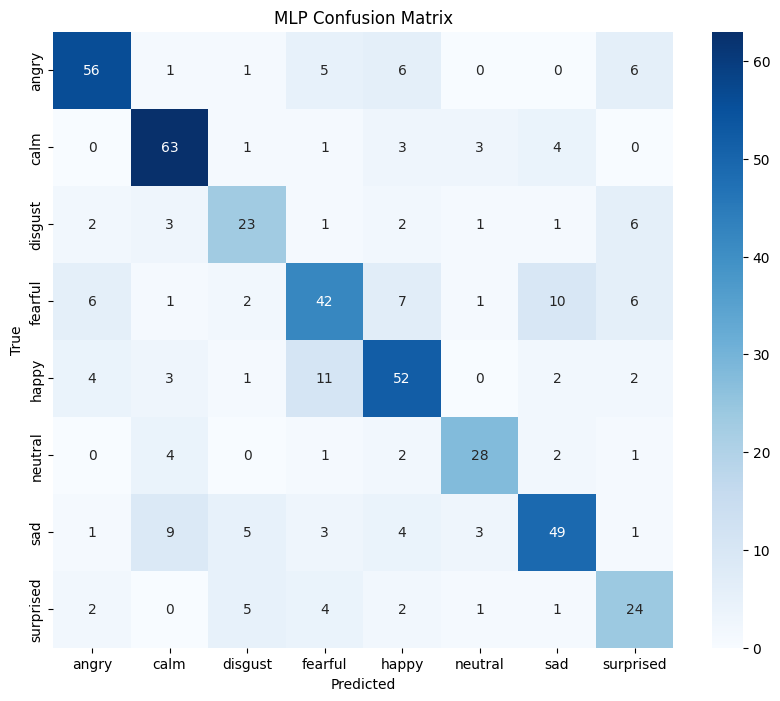

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('MLP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

This block saves all the trained models and preprocessing objects to your Google Drive



Saving Keras Model---
model.save('/content/drive/MyDrive/keras_model.h5')
model

Your trained Keras neural network.

.save()---Keras function used to save the entire model.

What Gets Saved?
architecture,
learned weights,
optimizer state,
training configuration,

File Path--
'/content/drive/MyDrive/keras_model.h5' means
save model into Google Drive

.h5--File extension for HDF5 format.Common format for storing deep learning models.

Then opening file for MLP Model

.pkl---Pickle file format.Used for saving Python objects

wb- write binary

dump()---Writes Python object into file.

Meaning

Save trained MLP model into file.


SAVING SCALAR

Why Save Scaler?

You scaled features using:StandardScaler() During Prediction

New audio must be scaled EXACTLY the same way.

Otherwise:

model input distribution changes predictions become inaccurate

SAVING LABEL ENCODER

Your model predicts encoded numbers.

Example:2

But humans need:happy

Label Encoder Converts Back le.inverse_transform([2])

Output:happy

In [ ]:
model.save('/content/drive/MyDrive/keras_model.h5')
with open('/content/drive/MyDrive/mlp_model.pkl', 'wb') as f:
    pickle.dump(mlp, f)
with open('/content/drive/MyDrive/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('/content/drive/MyDrive/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("\n✅ ALL DONE! Models saved to your Drive root.")


✅ ALL DONE! Models saved to your Drive root.


This code searches your RAVDESS dataset folder and finds all .wav audio files using a Linux command.

In [ ]:
#What is subprocess?Python module used to run system/Linux terminal commands from Python.
#subprocess.run()---Executes external terminal command.
#find	Linux search command
#/content/drive/MyDrive/RAVDESS	folder to search
#-name	search by filename
#"*.wav"	find all wav files
#capture_output=True---Stores terminal output inside Python variable. Without This Output would print directly to screen.
#text=True---Converts output into normal text string.
#result.stdout----Contains command output.
#.strip()---Removes extra spaces/newlines at beginning/end.
#.split('\n')---Splits text using newline separator.

import os
import subprocess

# Find all .wav files under RAVDESS
result = subprocess.run(['find', '/content/drive/MyDrive/RAVDESS', '-name', '*.wav'],
                        capture_output=True, text=True)
wav_files = result.stdout.strip().split('\n')
print(f"Found {len(wav_files)} .wav files.")
print("\nFirst 10 files with full paths:")
for f in wav_files[:10]:
    print(f)

Found 2452 .wav files.

First 10 files with full paths:
/content/drive/MyDrive/RAVDESS/Audio_Speech_Actors_01-24/Actor_21/03-01-01-01-01-01-21.wav
/content/drive/MyDrive/RAVDESS/Audio_Speech_Actors_01-24/Actor_21/03-01-01-01-02-02-21.wav
/content/drive/MyDrive/RAVDESS/Audio_Speech_Actors_01-24/Actor_21/03-01-02-01-02-02-21.wav
/content/drive/MyDrive/RAVDESS/Audio_Speech_Actors_01-24/Actor_21/03-01-02-01-01-02-21.wav
/content/drive/MyDrive/RAVDESS/Audio_Speech_Actors_01-24/Actor_21/03-01-01-01-02-01-21.wav
/content/drive/MyDrive/RAVDESS/Audio_Speech_Actors_01-24/Actor_21/03-01-02-01-01-01-21.wav
/content/drive/MyDrive/RAVDESS/Audio_Speech_Actors_01-24/Actor_21/03-01-01-01-01-02-21.wav
/content/drive/MyDrive/RAVDESS/Audio_Speech_Actors_01-24/Actor_21/03-01-02-01-02-01-21.wav
/content/drive/MyDrive/RAVDESS/Audio_Speech_Actors_01-24/Actor_21/03-01-03-02-02-01-21.wav
/content/drive/MyDrive/RAVDESS/Audio_Speech_Actors_01-24/Actor_21/03-01-05-02-01-01-21.wav


FINALLY TESTING THE MODEL ON A VOICE/AUDIO TO SEE THE RESULTS

In [ ]:
import pickle
import numpy as np
from tensorflow.keras.models import load_model
import librosa

# Load saved objects

#This code loads the previously saved Keras model, scaler, and label encoder from Google Drive
#so the trained Speech Emotion Recognition system can preprocess new audio data
#and predict emotions without retraining the model again



keras_model = load_model('/content/drive/MyDrive/keras_model.h5')
with open('/content/drive/MyDrive/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('/content/drive/MyDrive/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Feature extraction (same as before)
def extract_features(file_path, mfcc=True, chroma=True, mel=True, zcr=True):
    try:
        audio, sr = librosa.load(file_path, sr=None)
    except Exception:
        return None
    features = []
    if zcr:
        zcr_val = librosa.feature.zero_crossing_rate(audio)
        features.append(np.mean(zcr_val)); features.append(np.std(zcr_val))
    if mel:
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        features.append(np.mean(mel_spec_db)); features.append(np.std(mel_spec_db))
    if mfcc:
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        for coeff in mfccs:
            features.append(np.mean(coeff)); features.append(np.std(coeff))
    if chroma:
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        for val in chroma:
            features.append(np.mean(val)); features.append(np.std(val))
    return np.array(features, dtype=np.float32)


#This function takes an input audio file, extracts speech features from it,
#scales the features using the saved scaler, uses the trained Keras model to predict the emotion,
#finds the emotion with the highest prediction probability,
#and finally converts the predicted numerical label back into the actual emotion name like happy, sad, or angry.


def predict_emotion(file_path):
    feats = extract_features(file_path)
    if feats is None:
        return "Error extracting features"
    feats_scaled = scaler.transform([feats])
    pred = keras_model.predict(feats_scaled, verbose=0)
    idx = np.argmax(pred[0])
    return le.inverse_transform([idx])[0]

# ---- REPLACE THIS PATH WITH THE ONE YOU COPIED ----
test_file = '/content/drive/MyDrive/RAVDESS/Audio_Speech_Actors_01-24/Actor_21/03-01-03-02-02-01-21.wav'

if os.path.exists(test_file):
    emotion = predict_emotion(test_file)
    print(f"🎤 File: {os.path.basename(test_file)}")
    print(f"🧠 Predicted emotion: {emotion}")
else:
    print("❌ File not found. Double-check the path you copied.")

🎤 File: 03-01-03-02-02-01-21.wav
🧠 Predicted emotion: happy
